In [ ]:


import pandas as pd
import numpy as np
import os

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ===============================
# 1. LOAD DATA
# ===============================

def load_data(file_paths):
    dfs = []
    for file in file_paths:
        df = pd.read_csv(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# Example usage:
# files = ["cdi_data.csv", "cancer_risk.csv", "hi_tcr.csv"]
# data = load_data(files)

# ===============================
# 2. DATA CLEANING
# ===============================

def preprocess(df):
    # Standardize column names
    df.columns = df.columns.str.strip()

    # Replace empty strings and weird values with NaN
    df.replace(["", " ", "NA", "N/A", "nan"], np.nan, inplace=True)

    # Identify non-numeric columns
    non_numeric_cols = ['Sample', 'Metal']
    
    # Convert everything else to numeric safely
    for col in df.columns:
        if col not in non_numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Now fill NaN ONLY in numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)

    # Optional: fill categorical safely
    if 'Metal' in df.columns:
        df['Metal'] = df['Metal'].fillna("Unknown")

    return df

# ===============================
# 3. AGGREGATE BY SAMPLE
# ===============================

def aggregate_sample(df):
    agg = df.groupby('Sample').sum().reset_index()
    return agg

# ===============================
# 4. RISK CLASSIFICATION LOGIC
# ===============================

def classify_risk(row):
    score = 0

    # Non-carcinogenic (HI)
    hi = row['HI_dermal'] + row['HI_Ingestion'] + row['HI_Inhalation']
    
    if hi < 1:
        score += 1
    elif hi < 3:
        score += 2
    else:
        score += 3

    # Carcinogenic (TCR)
    tcr = row['TCR_dermal'] + row['TCR_Ingestion'] + row['TCR_Inhalation']
    
    if tcr < 1e-6:
        score += 1
    elif tcr < 1e-4:
        score += 2
    else:
        score += 3

    # Normalize into 1–5 scale
    if score <= 2:
        return 1
    elif score <= 3:
        return 2
    elif score <= 4:
        return 3
    elif score <= 5:
        return 4
    else:
        return 5

# ===============================
# 5. APPLY CLASSIFICATION
# ===============================

def apply_classification(df):
    df['Risk_Class'] = df.apply(classify_risk, axis=1)
    return df

# ===============================
# 6. MACHINE LEARNING DECISION TREE
# ===============================

def train_decision_tree(df):

    features = [
        'HI_dermal', 'HI_Ingestion', 'HI_Inhalation',
        'TCR_dermal', 'TCR_Ingestion', 'TCR_Inhalation'
    ]

    X = df[features]
    y = df['Risk_Class']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=3,
        random_state=42
    )

    model.fit(X_scaled, y)

    return model, scaler

# ===============================
# 7. VISUALIZE TREE
# ===============================

def plot_decision_tree_model(model, feature_names):
    plt.figure(figsize=(20,10))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=['1','2','3','4','5'],
        filled=True,
        rounded=True
    )
    plt.title("Health Risk Decision Tree")
    plt.savefig("decision_tree.png", dpi=300)
    plt.show()

# ===============================
# 8. PATHWAY-SPECIFIC CLASSIFICATION
# ===============================

def pathway_classification(df):
    
    df['Dermal_Risk'] = np.where(df['HI_dermal'] < 1, 1, 3)
    df['Ingestion_Risk'] = np.where(df['HI_Ingestion'] < 1, 1, 4)
    df['Inhalation_Risk'] = np.where(df['HI_Inhalation'] < 1, 1, 2)

    return df

# ===============================
# 9. EXPORT RESULTS
# ===============================

def export_results(df):
    df.to_csv("Final_Risk_Classification.csv", index=False)
    print("✅ Results exported successfully.")

# ===============================
# 10. MAIN EXECUTION PIPELINE
# ===============================

def main(file_paths):

    # Load
    df = load_data(file_paths)

    # Clean
    df = preprocess(df)

    # Aggregate
    df_sample = aggregate_sample(df)

    # Classification
    df_sample = apply_classification(df_sample)

    # Pathway analysis
    df_sample = pathway_classification(df_sample)

    # Train ML model
    model, scaler = train_decision_tree(df_sample)

    # Plot tree
    plot_decision_tree_model(model, [
        'HI_dermal', 'HI_Ingestion', 'HI_Inhalation',
        'TCR_dermal', 'TCR_Ingestion', 'TCR_Inhalation'
    ])

    # Export
    export_results(df_sample)

    return df_sample


# ===============================
# RUN
# ===============================

# Example:
# files = ["your_full_dataset.csv"]
# result = main(files)

In [8]:
def preprocess(df):
    # Standardize column names
    df.columns = df.columns.str.strip()

    # Replace empty strings and weird values with NaN
    df.replace(["", " ", "NA", "N/A", "nan"], np.nan, inplace=True)

    # Identify non-numeric columns
    non_numeric_cols = ['Sample', 'Metal']
    
    # Convert everything else to numeric safely
    for col in df.columns:
        if col not in non_numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Now fill NaN ONLY in numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)

    # Optional: fill categorical safely
    if 'Metal' in df.columns:
        df['Metal'] = df['Metal'].fillna("Unknown")

    return df

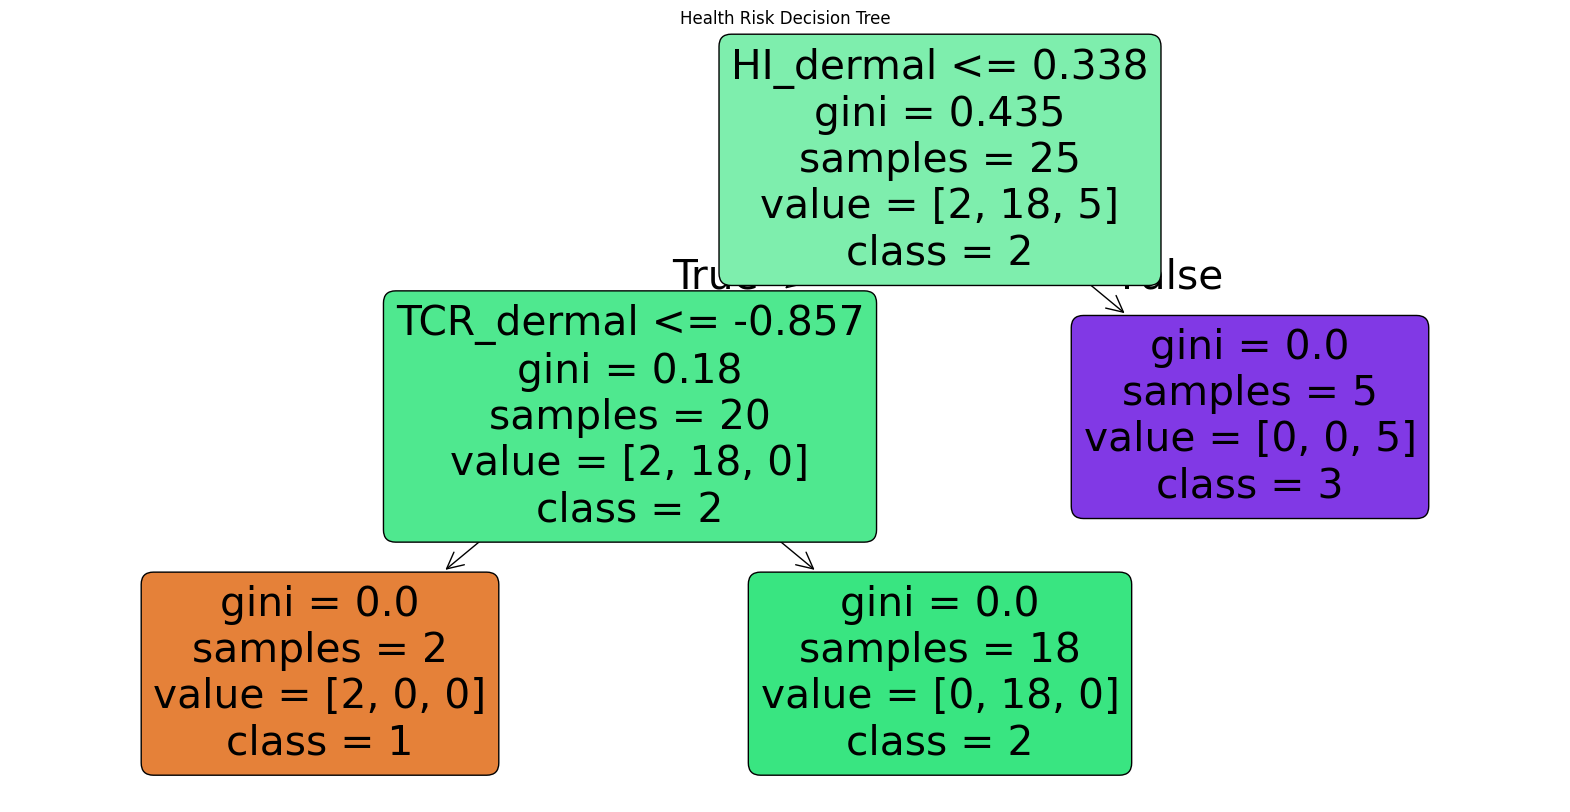

✅ Results exported successfully.


In [17]:
files = [
    "Ajakanga_output/Adult_risk/CDI_data.csv",
    "Ajakanga_output/Adult_risk/CR_data.csv",
    "Ajakanga_output/Adult_risk/Hi_n_TCR.csv"
]
result = main(files)